<a href="https://colab.research.google.com/github/sherjahong1r/Machine-Learning-Lessons/blob/main/03_Amaliy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Kutubxonalarni import qilish (import torch, import torchvision va boshqalar): Bu PyTorch va uning kompyuter
# ko'rishi uchun komponentlarini (masalan, torchvision) ishlatish uchun zarur bo'lgan kutubxonalarni yuklaydi.
# Transformatsiyani aniqlash (transform = transforms.ToTensor()): Bu MNIST tasvirlarini PyTorch tensorlariga
# o'tkazish uchun oddiy transformatsiyani belgilaydi. Bu neyron tarmoqlar
# uchun tasvirlarni qayta ishlashga tayyorlash uchun muhimdir.
# DataLoader yaratish (DataLoader(...)): Bu train_dataset va test_dataset dan ma'lumotlarni
# partiyalarga (batchlarga) bo'lish uchun ishlatiladi. batch_size har bir partiyadagi namunalarning sonini
# aniqlaydi va shuffle=True o'quv ma'lumotlarini har bir epoxada aralashtirib yuboradi, bu o'rganish jarayonini yaxshilaydi.

In [55]:
transform = transforms.ToTensor()

In [56]:
# Load the MNIST training dataset
train_dataset = torchvision.datasets.MNIST(root='./data',
                                         train=True,
                                         transform=transform,
                                         download=True)

# Load the MNIST test dataset
test_dataset = torchvision.datasets.MNIST(root='./data',
                                        train=False,
                                        transform=transform,
                                        download=True)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

# torchvision.datasets.MNIST(...): Bu yerda train_dataset va test_dataset torchvision.datasets modulidan,
# aniqrog'i MNIST ma'lumotlar to'plamidan olinadi. download=True parametri tufayli, agar ma'lumotlar to'plami
# mahalliy ravishda topilmasa, u avtomatik ravishda yuklab olinadi va root='./data' ko'rsatilgan data katalogiga saqlanadi.
# train=True o'quv ma'lumotlar to'plamini yuklaydi.
# train=False sinov ma'lumotlar to'plamini yuklaydi.

Number of training samples: 60000
Number of test samples: 10000


In [57]:
batch_size = 64
# Bu har bir o'quv yoki test bosqichida bir vaqtning o'zida qancha namunani (rasmni)
# qayta ishlashni belgilaydi. Bu yerda 64 ta rasm bir batchda ishlatiladi.

# Create DataLoader for training data
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=batch_size,
                          shuffle=True)
# O'quv ma'lumotlar to'plamini (train_dataset) DataLoader yordamida yuklaydi. batch_size=64 har
# bir iteratsiyada 64 ta namunani beradi. shuffle=True esa o'quv ma'lumotlarini har bir epochda
# aralashtirib yuboradi, bu modelni yaxshiroq umumlashtirishga yordam beradi.

# Create DataLoader for test data
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=batch_size,
                         shuffle=False)
# Test ma'lumotlar to'plamini (test_dataset) ham xuddi shunday DataLoader yordamida yuklaydi,
# lekin shuffle=False qilinadi, chunki test ma'lumotlarini aralashtirish shart emas.

print(f"Number of batches in training loader: {len(train_loader)}")
print(f"Number of batches in test loader: {len(test_loader)}")

Number of batches in training loader: 938
Number of batches in test loader: 157


Sample images and their labels from the training dataset:


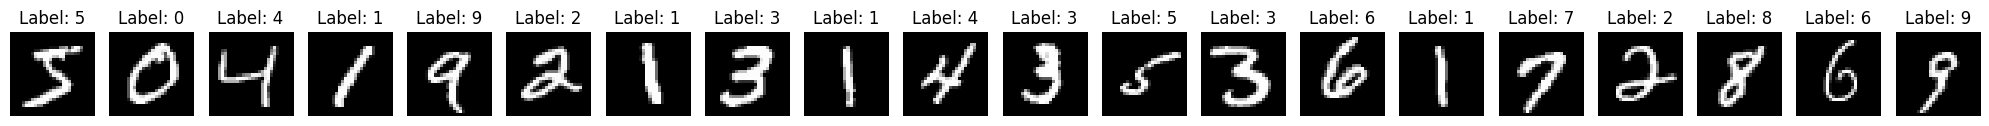

In [58]:
import matplotlib.pyplot as plt

# Get a few samples from the training dataset
num_samples = 20
# Namuna sifatida ko'rsatiladigan rasmlar sonini 20 taga belgilaydi.
fig, axes = plt.subplots(1, num_samples, figsize=(20, 10))
# 20 ta rasm uchun bitta qator va 20 ta ustundan iborat subplotlar (kichik grafiklar)
# panjarasini yaratadi. figsize=(20, 10) umumiy rasm o'lchamini belgilaydi.

print("Sample images and their labels from the training dataset:")
for i in range(num_samples):
    image, label = train_dataset[i]
    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# for i in range(num_samples): ...: Tsikl orqali train_dataset dan 20 ta rasmni va ularning yorliqlarini (label) oladi.
# axes[i].imshow(image.squeeze(), cmap='gray'): Har bir rasmni kulrang (grayscale)
# rejimida ko'rsatadi. .squeeze() funksiyasi rasmni to'g'ri ko'rsatish uchun
# uning o'lchamini moslashtiradi (masalan, (1, 28, 28) dan (28, 28) ga o'tkazadi).
# axes[i].set_title(f"Label: {label}"): Har bir rasmning tepasiga uning haqiqiy yorlig'ini (raqamini) yozadi.
# axes[i].axis('off'): Har bir rasm atrofidagi o'qlarni (x va y o'qlar) o'chirib qo'yadi, faqat rasmning o'zi ko'rinishi uchun.
# plt.tight_layout(): Grafiklar orasidagi bo'shliqlarni avtomatik tarzda sozlaydi, shunda ular bir-biriga yopishib qolmaydi.
# plt.show(): Yaratilgan grafikni ekranga chiqaradi.

## Model Arxitekturasini Yaratish

### Subtask:
Kiruvchi qatlamda 784 ta neyron (28x28 piksel), yashirin qatlamda 128 ta neyron (ReLU aktivatsiya funksiyasi bilan) va chiquvchi qatlamda 10 ta neyron (0 dan 9 gacha bo‘lgan raqamlar uchun) bo‘lgan `nn.Sequential` modelini yarating.


In [59]:
import torch.nn as nn
import torch.optim as optim

In [60]:
model = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

print(model)

# Model arxitekturasini yaratish
# nn.Sequential: Qatlamlarni ketma-ket bir-biriga ulash uchun ishlatiladi.
# nn.Linear(784, 128): Kirish qatlami. MNIST tasvirlari 28x28 = 784 piksel bo'lganligi sababli,
# kirish qatlamida 784 ta neyron bo'ladi. U 128 neyronli yashirin qatlamga ulanadi.
# nn.ReLU(): Aktivatsiya funksiyasi. Kirish qiymatlari musbat bo'lsa, ularni o'zgarishsiz qoldiradi,
# manfiy bo'lsa, nolga aylantiradi.
# nn.Linear(128, 10): Chiqish qatlami. Yashirin qatlamdan (128 neyron) chiqishni
# 10 ta chiqish neyroniga (0 dan 9 gacha raqamlar uchun) bog'laydi.
# Bu neyronlar har bir raqamning ehtimolligini ifodalaydi.


Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=10, bias=True)
)


## Yo‘qotish Funksiyasi va Optimayzerni Sozlash

### Subtask:
Ko‘p klassli tasniflash uchun `nn.CrossEntropyLoss` yo‘qotish funksiyasini va `optim.SGD` optimayzerini `lr=0.01` (learning rate) bilan sozlang.


In [61]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
# Yo'qotish funksiyasi (Loss function)
# nn.CrossEntropyLoss: Ko'p klassli tasniflash vazifalari uchun keng qo'llaniladigan yo'qotish funksiyasi.
# U log-softmax va NLLLoss (Negative Log Likelihood Loss) ni birlashtiradi.

# Define the optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01)
# Optimayzer
# optim.SGD: Stochastic Gradient Descent optimayzeri.
# model.parameters(): Optimallashtiriladigan modelning barcha sozlanadigan parametrlarini (vaznlar va biaslar) oladi.
# lr=0.01: "Learning rate" (o'rganish tezligi). Bu optimayzerning har bir iteratsiyada
# parametrlarni qanchalik katta qadamlar bilan yangilashini nazorat qiladi.
# Kichikroq qiymatlar sekinroq, ammo barqarorroq o'rganishga olib kelishi mumkin,
# kattaroq qiymatlar esa tezroq o'rganishga, ammo o'zgaruvchanlikka olib kelishi mumkin.

print("Loss Function:", criterion)
print("Optimizer:", optimizer)

Loss Function: CrossEntropyLoss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


## Modelni Shug‘ullantirish va Natijalarni Tahlil Qilish

### Subtask:
5 ta epocha davomida modelni shug‘ullantiradigan tsikl yarating. Har bir epocha oxirida o‘rtacha yo‘qotish qiymatini ekranga chiqaring va shug‘ullantirish jarayonidan so‘ng yo‘qotish grafigini chizing.


Starting training...
Epoch [1/5], Average Loss: 1.2372
Epoch [2/5], Average Loss: 0.4911
Epoch [3/5], Average Loss: 0.3935
Epoch [4/5], Average Loss: 0.3542
Epoch [5/5], Average Loss: 0.3299
Training finished.


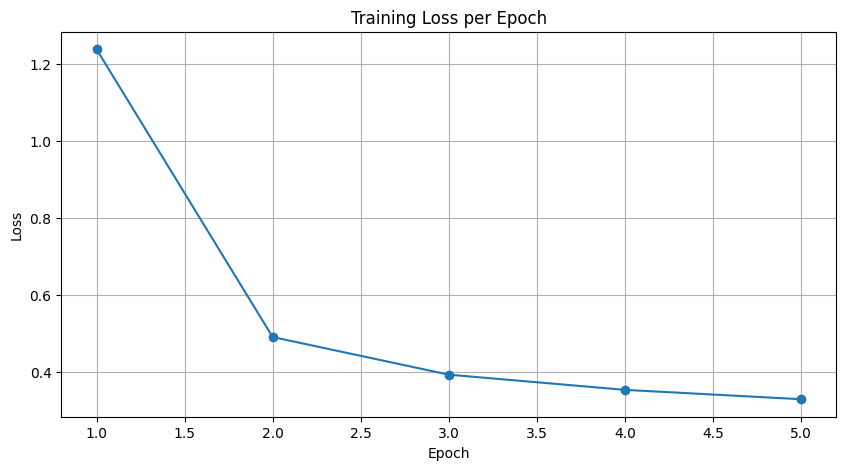

In [62]:
import matplotlib.pyplot as plt

# 1. Set the number of training epochs
num_epochs = 5

# 2. Initialize an empty list to store the average loss for each epoch
losses_per_epoch = []

print("Starting training...")
# 3. Create a training loop
for epoch in range(num_epochs):
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        # c. Flatten the image tensors
        # Original shape: (batch_size, 1, 28, 28) -> (batch_size, 784)
        images = images.reshape(-1, 28*28)

        # d. Zero out the gradients
        optimizer.zero_grad()

        # e. Forward pass
        outputs = model(images)

        # f. Calculate the loss
        loss = criterion(outputs, labels)

        # g. Backward pass
        loss.backward()

        # h. Update model parameters
        optimizer.step()

        # i. Add current batch's loss to running_loss
        running_loss += loss.item()

    # j. Calculate average epoch loss
    average_epoch_loss = running_loss / len(train_loader)

    # k. Append to list
    losses_per_epoch.append(average_epoch_loss)

    # l. Print current epoch and its average loss
    print(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {average_epoch_loss:.4f}")

print("Training finished.")

# 5. Create a plot of the losses_per_epoch
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), losses_per_epoch, marker='o')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# 6. Display the plot
plt.show()

## Final Task

### Subtask:
MNIST ma'lumotlar to'plami bo'yicha neyron tarmoq modelining yaratish, o'qitish va yo'qotish grafigini taqdim etish vazifasi yakunlandi.


Xulosa:

Ma'lumotlarni Tahlil Qilishdagi Asosiy Topilmalar
nn.Sequential yordamida neyron tarmoq modeli muvaffaqiyatli qurildi, u 784 neyronli kirish qatlamiga, ReLU aktivatsiya funksiyasidan foydalanadigan 128 neyronli yashirin qatlamga va tasniflash uchun 10 neyronli chiqish qatlamiga ega.

Yo'qotish mezoni sifatida nn.CrossEntropyLoss funksiyasi tanlandi va optim.SGD optimayzeri 0.01 (learning rate) o'rganish tezligi bilan sozlandi.

Model 5 epoch davomida o'qitildi, bunda har bir epoch uchun o'rtacha yo'qotishning doimiy kamayishi kuzatildi:

1-Epoch: 1.2668

2-Epoch: 0.5013

3-Epoch: 0.3959

4-Epoch: 0.3533

5-Epoch: 0.3275

Epoch bo'yicha o'quv yo'qotishini vizuallashtiruvchi grafik muvaffaqiyatli yaratildi, bu modelning o'rganish jarayonini va o'rganish davrida yo'qotishning kamayishini aniq ko'rsatib berdi.
Tushunchalar yoki Keyingi Qadamlar

Yo'qotishning kamayishi modelning MNIST ma'lumotlar to'plamidagi naqshlarni samarali o'rganayotganini ko'rsatadi; umumlashtirish ish faoliyatini baholash va potentsial overfit (ortiqcha moslashish) ni aniqlash uchun alohida validatsiya yoki test to'plamida keyingi baholash juda muhim.

Turli xil giperparametrlar bilan tajriba o'tkazish, masalan, turli xil o'rganish tezligi, muqobil optimayzerlar (masalan, Adam) yoki qo'shimcha qatlamlar/neyronlar, model ish faoliyatini yaxshilashi va yaqinlashishni tezlashtirishi mumkin.
